In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!unzip "/content/drive/MyDrive/Colab Notebooks/dataset.zip" -d "/content/drive/MyDrive/Colab Notebooks/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_1020.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_0458.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_0504.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_0262.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_0276.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_1168.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_0510.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_0538.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_1140.jpg  
  inflating: /content/drive/MyDrive/Colab Notebooks/dataset/Training/notumor/Tr-no_1154.jpg  
  inflati

In [8]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [13]:
train_data_path = '/content/drive/MyDrive/Colab Notebooks/dataset/Training'
filepaths = []
labels = []

folds = os.listdir(train_data_path)

for fold in folds:
    f_path = os.path.join(train_data_path, fold)
    if os.path.isdir(f_path):
        filelist = os.listdir(f_path)

        for file in filelist:
            filepaths.append(os.path.join(f_path, file))
            labels.append(fold)

##Concat data path with labels
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='label')
train_df = pd.concat([Fseries, Lseries], axis=1)

In [14]:
train_df

,filepaths,label
0,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
1,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
2,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
3,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
4,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
...,...,...
5707,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma
5708,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma
5709,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma
5710,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma


In [16]:
test_data_path = '/content/drive/MyDrive/Colab Notebooks/dataset/Training'

filepaths = []
labels = []

# list folders (class names)
folds = os.listdir(test_data_path)

for fold in folds:
    f_path = os.path.join(test_data_path, fold)

    # cek kalau memang folder
    if os.path.isdir(f_path):
        filelists = os.listdir(f_path)

        for file in filelists:
            filepaths.append(os.path.join(f_path, file))
            labels.append(fold)

# convert to series
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='label')

# concat ke dataframe
test_df = pd.concat([Fseries, Lseries], axis=1)

In [17]:
test_df

,filepaths,label
0,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
1,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
2,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
3,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
4,/content/drive/MyDrive/Colab Notebooks/dataset...,pituitary
...,...,...
5707,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma
5708,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma
5709,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma
5710,/content/drive/MyDrive/Colab Notebooks/dataset...,meningioma


Data split

In [18]:
from sklearn.model_selection import train_test_split

train, valid = train_test_split(train_df, test_size=0.2, shuffle=True, stratify=train_df['label'])
valid, test = train_test_split(valid, test_size=0.5, shuffle=True, stratify=valid['label'])


In [19]:
img_size = (224 ,244)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'filepaths' , y_col = 'label' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'filepaths' , y_col = 'label' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'filepaths' , y_col = 'label' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 5712 validated image filenames belonging to 4 classes.
Found 571 validated image filenames belonging to 4 classes.
Found 572 validated image filenames belonging to 4 classes.


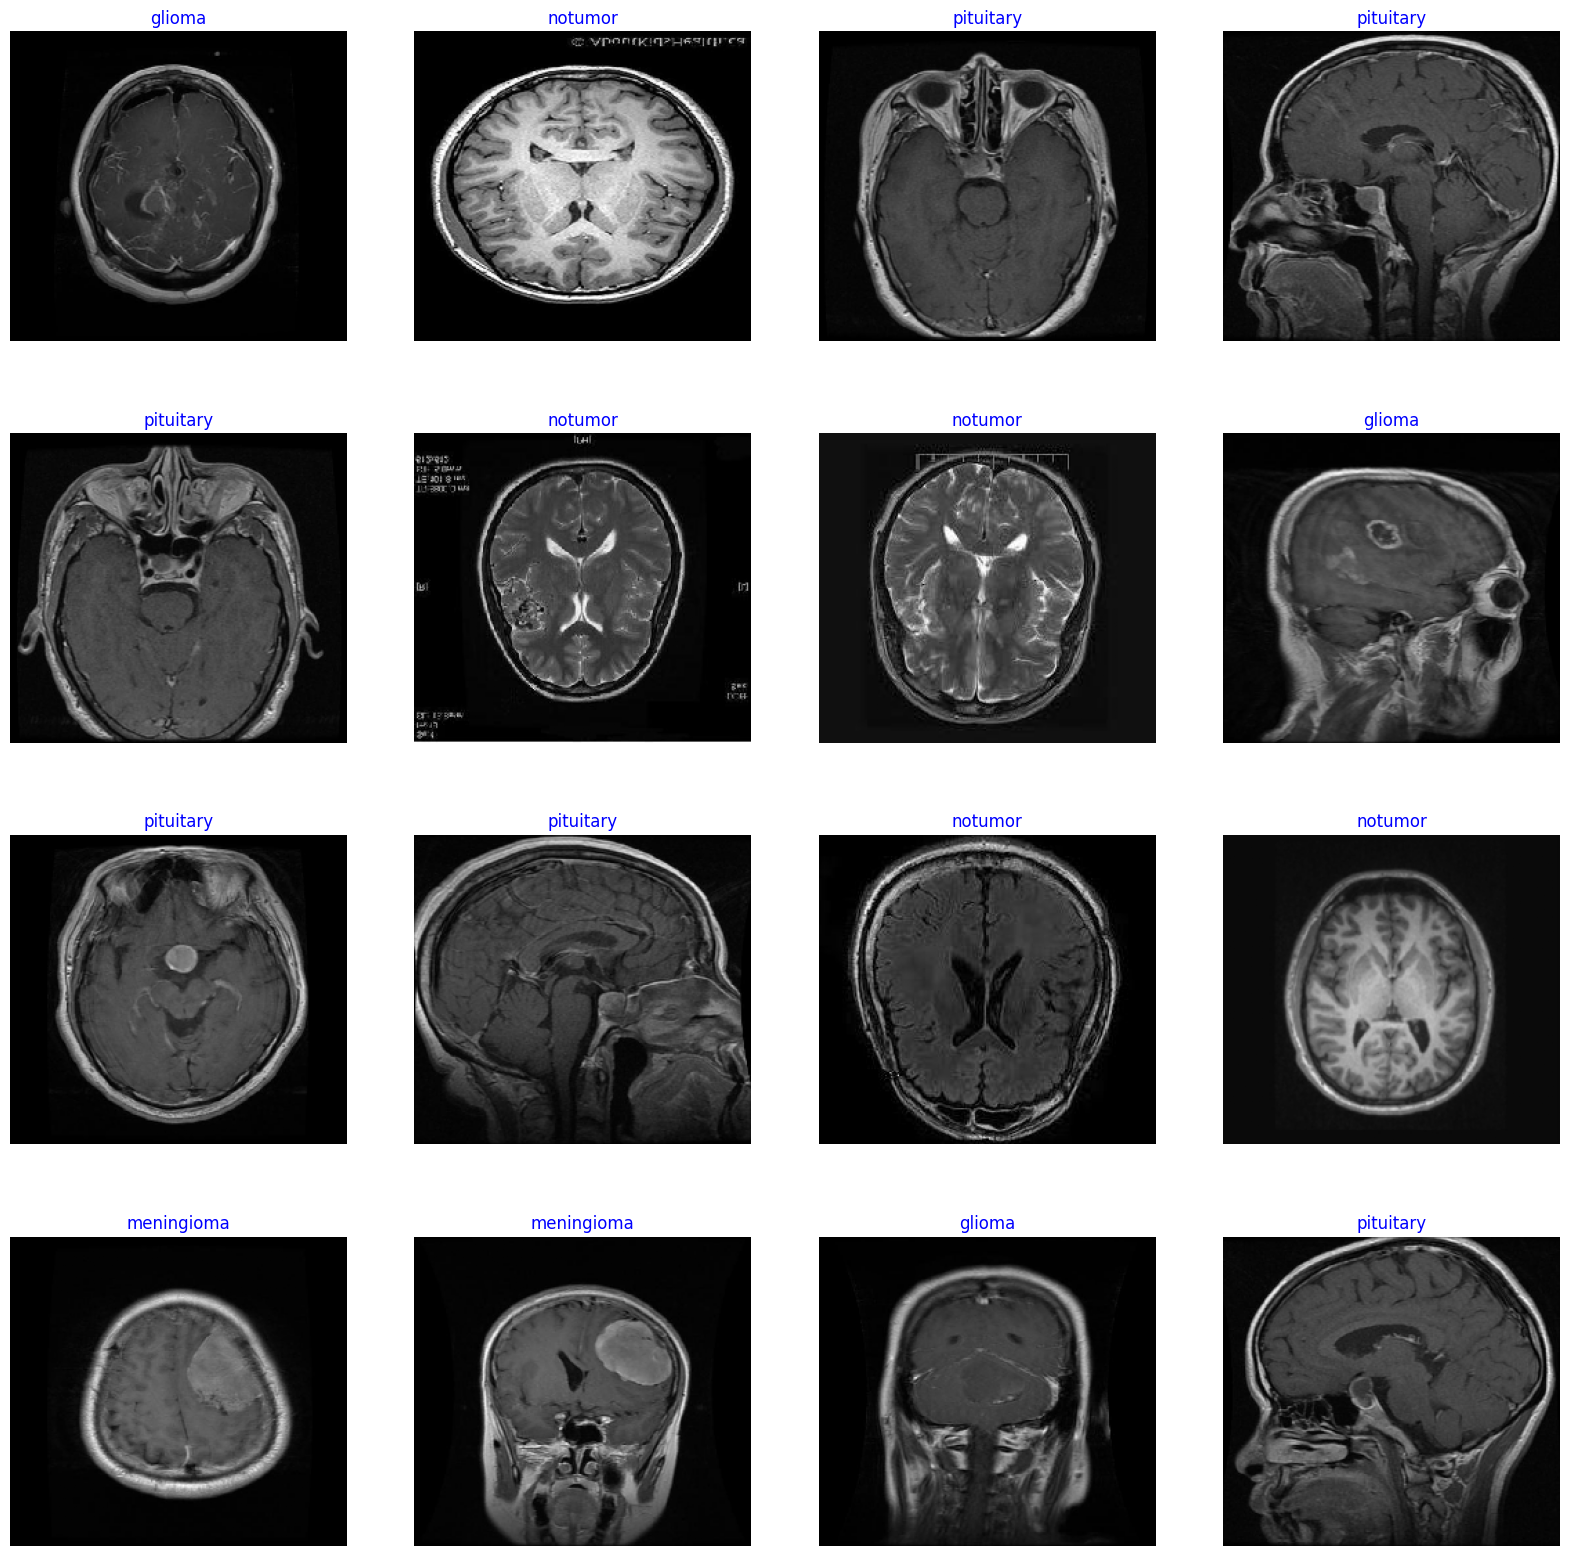

In [20]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize = (20,20))

for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i]/255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color = "blue", fontsize = 12)
    plt.axis("off")
plt.show();

building

In [21]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 6,190,228 (23.61 MB)

 Non-trainable params: 63,168 (246.75 KB)

training model

In [22]:
Epochs = 10

history = model.fit(
    train_gen,
    epochs=Epochs,
    verbose=1,
    validation_data=valid_gen,
    shuffle=True
)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1735s 5s/step - accuracy: 0.5956 - loss: 10.3338 - val_accuracy: 0.5989 - val_loss: 5.5265
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1693s 5s/step - accuracy: 0.5073 - loss: 5.0210 - val_accuracy: 0.6130 - val_loss: 3.6571
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1680s 5s/step - accuracy: 0.5461 - loss: 3.3513 - val_accuracy: 0.7496 - val_loss: 2.4668
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1740s 5s/step - accuracy: 0.6211 - loss: 2.3110 - val_accuracy: 0.8511 - val_loss: 1.6709
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1681s 5s/step - accuracy: 0.7695 - loss: 1.6599 - val_accuracy: 0.9405 - val_loss: 1.2005
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1729s 5s/step - accuracy: 0.7971 - loss: 1.2899 - val_accuracy: 0.9632 - val_loss: 0.8982
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1684s 5s/step - accuracy: 0.8315 - loss: 1.0281 - val_accuracy: 0.9737 - val_loss: 0.7369
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 1690s 5s/step - accuracy: 0.8597 - loss: 0.8807 -

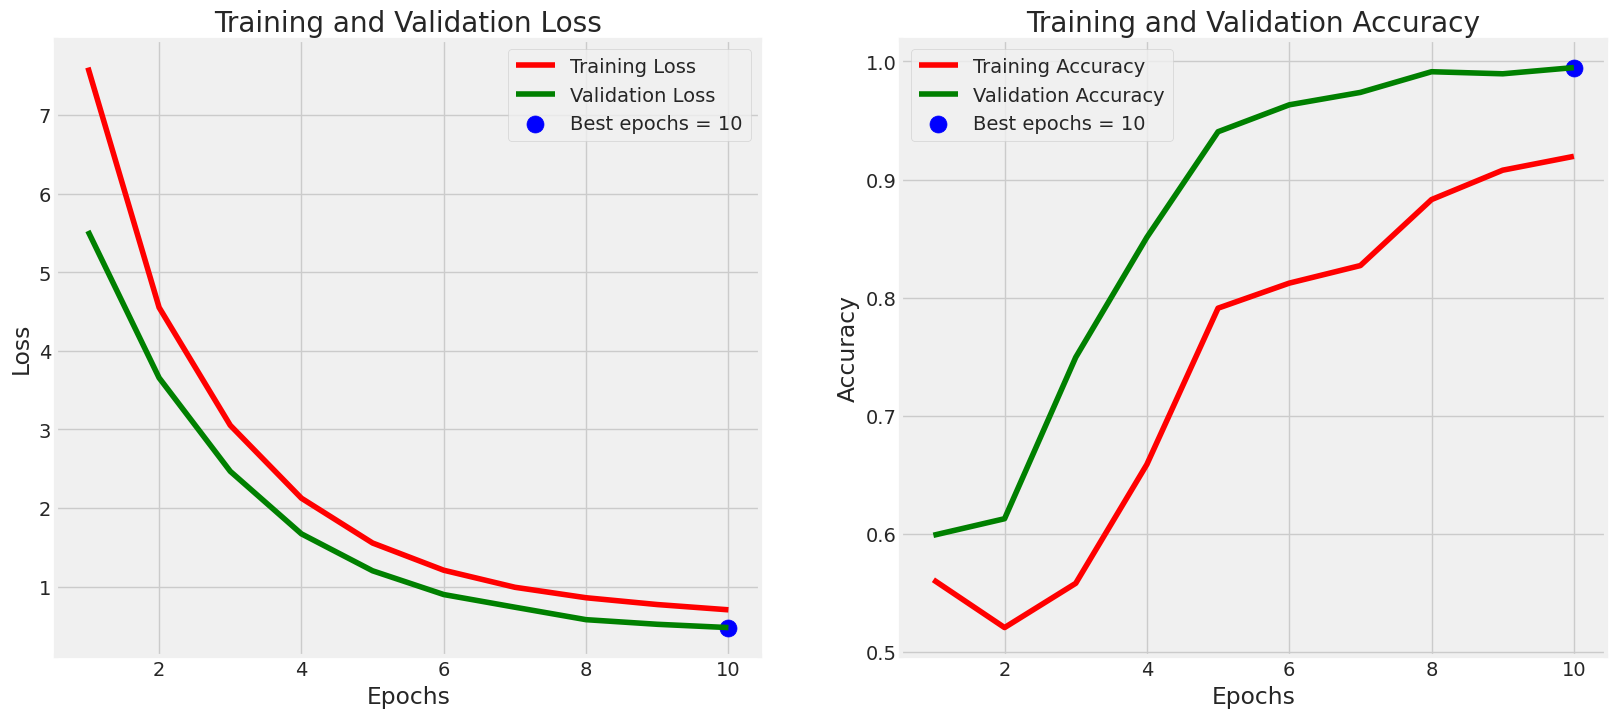

In [23]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show();

In [24]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9914 - loss: 0.4807
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9919 - loss: 0.4858
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9888 - loss: 0.4809
Train Loss:  0.4913945496082306
Train Accuracy:  0.984375
--------------------
Validation Loss:  0.4901620149612427
Validation Accuracy:  0.9921875
--------------------
Test Loss:  0.47791773080825806
Test Accuracy:  0.9921875


In [25]:
preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

36/36 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step


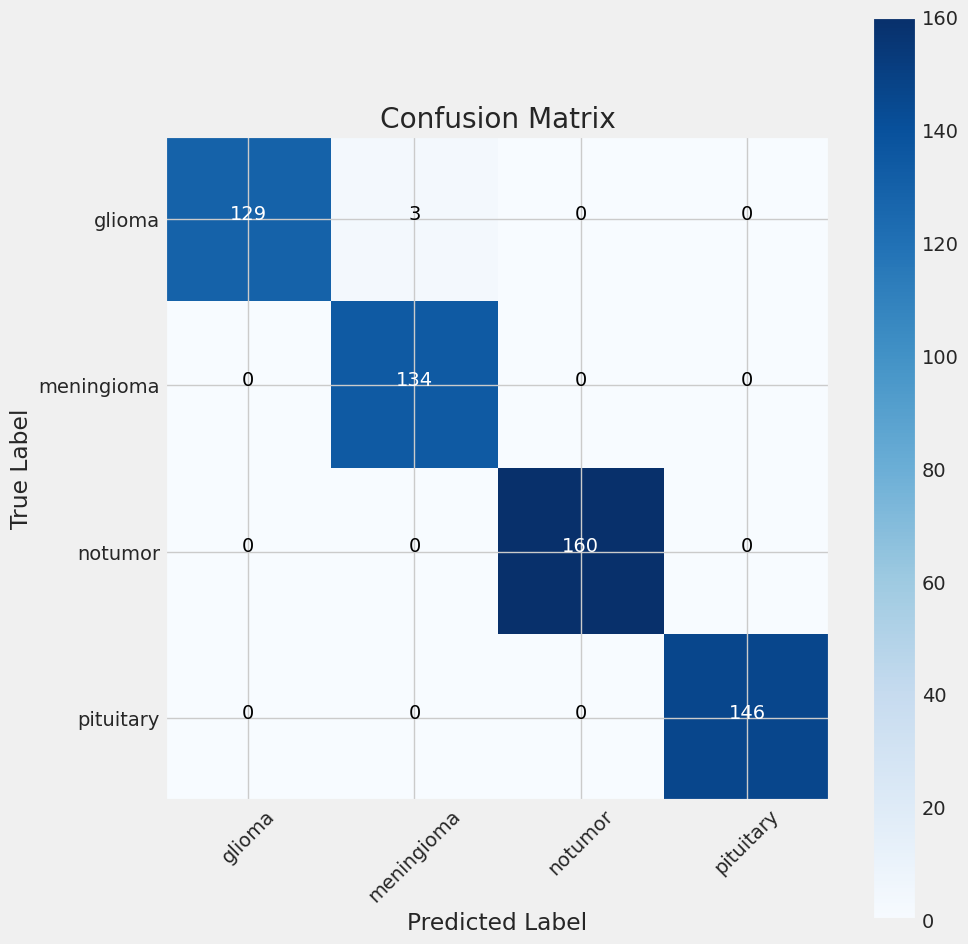

In [26]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [27]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       132
  meningioma       0.98      1.00      0.99       134
     notumor       1.00      1.00      1.00       160
   pituitary       1.00      1.00      1.00       146

    accuracy                           0.99       572
   macro avg       0.99      0.99      0.99       572
weighted avg       0.99      0.99      0.99       572



saving model

In [28]:
model.save("model.h5")

In [29]:
from keras.models import load_model
from keras.preprocessing import image
import numpy as np

In [30]:
model = load_model('model.h5', compile=False)
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [31]:
gambar = tf.keras.preprocessing.image.load_img('/content/drive/MyDrive/Colab Notebooks/dataset/Testing/glioma/Te-glTr_0000.jpg', target_size=img_size)

In [32]:
input_arr = tf.keras.preprocessing.image.img_to_array(gambar)

In [33]:
input_arr = np.array([input_arr])
prediksi = model.predict(input_arr)
predicted_class = np.argmax(prediksi, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [34]:
print(predicted_class)

[0]


In [35]:
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [36]:
names = [classes[i] for i in predicted_class]
print(names)

['glioma']
